In [1]:
pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

/Users/lilyal/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
# Cargar los tickers desde tu archivo
with open('SP500_tickernames.txt', 'r') as f:
    tickers = [line.strip() for line in f.readlines() if line.strip()]



In [4]:
# Definir rango de fechas
start_date = "2023-01-01"
end_date = "2023-12-31"

In [5]:
#Obtener datos históricos (Precios de Cierre)
print("Descargando datos...")
data = yf.download(tickers, start=start_date, end=end_date)['Close']

# Limpiar datos: Eliminar tickers con valores nulos (acciones que no cotizaron en el periodo)
data_clean = data.dropna(axis=1)

Descargando datos...


[*                      3%                       ]  13 of 495 completed$ANTM: possibly delisted; no timezone found
[**                     5%                       ]  24 of 495 completedHTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: CMA"}}}
$PBCT: possibly delisted; no timezone found
[**                     5%                       ]  26 of 495 completed$RE: possibly delisted; no timezone found
[***                    7%                       ]  37 of 495 completed$CMA: possibly delisted; no timezone found
[****                   8%                       ]  42 of 495 completed$JNPR: possibly delisted; no timezone found
$PEAK: possibly delisted; no timezone found
[******                12%                       ]  61 of 495 completed$VIAC: possibly delisted; no timezone found
[*******               15%                       ]  75 of 495 completed$K: possibly delisted; no timezone found
[*********             19%     

In [6]:
# Transponer para que: Filas = Acciones, Columnas = Días
matrix = data_clean.T 

#Visualicemos los primeros 10 registros para verificar la estructura
matrix.head(10)

Date,2023-01-03,2023-01-04,2023-01-05,2023-01-06,2023-01-09,2023-01-10,2023-01-11,2023-01-12,2023-01-13,2023-01-17,...,2023-12-15,2023-12-18,2023-12-19,2023-12-20,2023-12-21,2023-12-22,2023-12-26,2023-12-27,2023-12-28,2023-12-29
Ticker,,,,,,,,,,,,,,,,,,,,,
A,146.415787,148.006470,148.435791,144.103073,143.907883,151.480453,154.349426,152.710037,153.129608,151.646332,...,134.218948,134.954880,137.172546,135.592697,136.338486,136.956696,137.192184,137.202026,137.152954,136.657532
AAL,12.740000,13.590000,13.990000,14.180000,14.610000,15.190000,15.340000,16.830000,17.020000,17.080000,...,14.490000,14.240000,14.300000,13.980000,14.350000,14.310000,14.110000,13.990000,13.980000,13.740000
AAP,141.041733,141.367493,142.549500,143.349945,141.711868,141.441956,142.661209,141.646744,140.567093,138.873184,...,59.605896,57.648170,57.838249,56.498257,57.676689,58.208885,57.895267,58.503490,58.436974,57.999802
AAPL,123.096016,124.365662,123.046806,127.574203,128.095840,128.666702,131.383102,131.304382,132.633102,133.794464,...,195.538681,193.875931,194.915131,192.826813,192.678329,191.609467,191.065125,191.164078,191.589676,190.550476
ABBV,143.135162,144.289932,144.113602,146.810898,142.500504,140.719879,138.542648,135.454819,136.682846,135.997635,...,141.268982,140.700378,140.865479,139.113815,139.939209,142.094376,141.800888,142.039368,141.920120,142.121887
ABT,102.208000,103.728340,103.345924,104.772995,104.605095,106.190735,105.537834,104.338539,106.352974,106.240547,...,102.073997,102.806557,103.149071,102.178650,103.206139,103.729393,103.919693,104.452461,105.032806,104.718849
ACN,255.968201,255.096832,249.073181,254.973724,259.273621,260.391266,267.304932,269.929596,268.312988,270.918762,...,331.129425,328.916412,328.589264,326.655334,335.555389,341.039764,340.058319,340.433563,338.287933,337.633636
ADBE,336.920013,341.410004,328.440002,332.750000,341.980011,338.700012,342.929993,344.540009,344.380005,344.380005,...,584.679993,599.130005,604.640015,596.059998,600.140015,598.750000,598.260010,596.080017,595.520020,596.599976
ADI,153.730545,157.004837,151.118698,156.635788,158.130951,160.137146,160.676605,159.616699,159.910065,157.951187,...,193.717972,189.580902,190.776703,185.337784,189.281967,190.072739,191.779602,192.242523,193.100754,191.480682


In [7]:
# Estandarización (Media 0, Varianza 1)
scaler = StandardScaler()
matrix_scaled = scaler.fit_transform(matrix)

# Convertir de vuelta a DataFrame para mantener etiquetas
df_final = pd.DataFrame(matrix_scaled, index=matrix.index, columns=matrix.columns)

In [8]:
# Calcular el porcentaje de retorno total por cada ticket
# (Precio Final / Precio Inicial) - 1
retornos = (data_clean.iloc[-1] / data_clean.iloc[0]) - 1

# Convertir a porcentaje para mejor lectura
retornos_pct = retornos * 100

print(retornos_pct.head())

Ticker
A       -6.664756
AAL      7.849294
AAP    -58.877560
AAPL    54.798248
ABBV    -0.707915
dtype: float64


In [10]:
pip install kmapper

Defaulting to user installation because normal site-packages is not writeable
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp39-cp39-macosx_11_0_arm64.whl.metadata (2.7 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached markupsafe-3.0.3-cp39-cp39-macosx_11_0_arm64.whl (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [kmapper]
Note: you may need to restart the kernel to use updated packages.


In [11]:
#utilicemos el algoritmo de kmapper para analizar la topología de los datos
from kmapper import KeplerMapper    

In [13]:
import kmapper as km
import matplotlib.pyplot as plt
import numpy as np

In [16]:
#Veamos el kmapper usando la funcion de retornos como filtro
mapper = km.KeplerMapper(verbose=1)
#Usamos los retornos como filtro
lens = retornos_pct.values.reshape(-1, 1)  # Convertir a formato adecuado para kmapper

#Construimos el grafo de kmapper
graph = mapper.map(lens, df_final.values, cover=km.Cover(n_cubes=10, perc_overlap=0.2), clusterer=km.cluster.DBSCAN(eps=0.5, min_samples=5))    



KeplerMapper(verbose=1)
Mapping on data shaped (453, 250) using lens shaped (453, 1)

Creating 10 hypercubes.

Created 7 edges and 10 nodes in 0:00:00.012084.


In [19]:
#Visualizamos el grafo
mapper.visualize(graph, 
                 path_html="mapper_sp500.html", 
                 title="Mapper SP500", 
                 color_function_name="Retornos (%)",
                 node_color_function=(['average','std','sum','max','min'])
                 )    

Wrote visualization to: mapper_sp500.html


/Users/lilyal/Library/Python/3.9/lib/python/site-packages/kmapper/kmapper.py:872: UserWarning: `color_function_name` was set -- however, no `color_values` were passed, so default color_values were computed based on row order, and the passed `color_function_name` will be set as their label. This may be unexpected.
  warnings.warn(
/Users/lilyal/Library/Python/3.9/lib/python/site-packages/kmapper/visuals.py:344: RuntimeWarning: invalid value encountered in scalar divide
  height = np.floor(((bar / max_bucket_value) * 100) + 0.5)
/Users/lilyal/Library/Python/3.9/lib/python/site-packages/kmapper/visuals.py:345: RuntimeWarning: invalid value encountered in scalar divide
  perc = round((bar / sum_bucket_value) * 100.0, 1)


'<!DOCTYPE html>\n<html>\n\n<head>\n  <meta charset="utf-8">\n  <meta name="generator" content="KeplerMapper">\n  <title>Mapper SP500 | KeplerMapper</title>\n\n  <link rel="icon" type="image/png" href="http://i.imgur.com/axOG6GJ.jpg" />\n\n  <link href=\'https://fonts.googleapis.com/css?family=Roboto+Mono:700,300\' rel=\'stylesheet\' type=\'text/css\'>\n  <style>* {\n  margin: 0;\n  padding: 0;\n}\n\nhtml, body {\n  height: 100%;\n}\n\nbody {\n  font-family: "Roboto Mono", "Helvetica", sans-serif;\n  font-size: 14px;\n}\n\n#logo {\n  width:  85px;\n  height: 85px;\n}\n\n#display {\n  color: #95A5A6;\n  background: #212121;\n}\n\n#header {\n  background: #111111;\n}\n\n#print {\n  color: #000;\n  background: #FFF;\n}\n\nh1 {\n  font-size: 21px;\n  font-weight: 300;\n  font-weight: 300;\n}\n\nh2 {\n  font-size: 18px;\n  padding-bottom: 20px;\n  font-weight: 300;\n}\n\nh3 {\n  font-size: 14px;\n  font-weight: 700;\n  text-transform: uppercase;\n}\n\nh4 {\n  font-size: 13px;\n  font-weight

In [21]:
#Veamos las estadisticas de cada nodo
for node in graph['nodes']:
    indices = graph['nodes'][node]
    print(f"Nodo {node}:")
    print(f"  Número de acciones: {len(indices)}")
    print(f"  Retorno promedio: {retornos_pct.iloc[indices].mean():.2f}%")
    print(f"  Retorno máximo: {retornos_pct.iloc[indices].max():.2f}%")
    print(f"  Retorno mínimo: {retornos_pct.iloc[indices].min():.2f}%")
    print() 

Nodo cube1_cluster0:
  Número de acciones: 83
  Retorno promedio: -10.69%
  Retorno máximo: -0.69%
  Retorno mínimo: -32.88%

Nodo cube2_cluster0:
  Número de acciones: 159
  Retorno promedio: 7.52%
  Retorno máximo: 29.18%
  Retorno mínimo: -8.00%

Nodo cube2_cluster1:
  Número de acciones: 11
  Retorno promedio: 16.57%
  Retorno máximo: 29.95%
  Retorno mínimo: -0.86%

Nodo cube2_cluster2:
  Número de acciones: 5
  Retorno promedio: 11.65%
  Retorno máximo: 24.78%
  Retorno mínimo: -3.64%

Nodo cube2_cluster3:
  Número de acciones: 5
  Retorno promedio: 4.33%
  Retorno máximo: 29.22%
  Retorno mínimo: -6.73%

Nodo cube3_cluster0:
  Número de acciones: 27
  Retorno promedio: 36.97%
  Retorno máximo: 59.45%
  Retorno mínimo: 23.97%

Nodo cube3_cluster1:
  Número de acciones: 22
  Retorno promedio: 35.39%
  Retorno máximo: 57.11%
  Retorno mínimo: 24.78%

Nodo cube3_cluster2:
  Número de acciones: 9
  Retorno promedio: 36.95%
  Retorno máximo: 56.10%
  Retorno mínimo: 24.58%

Nodo cube4

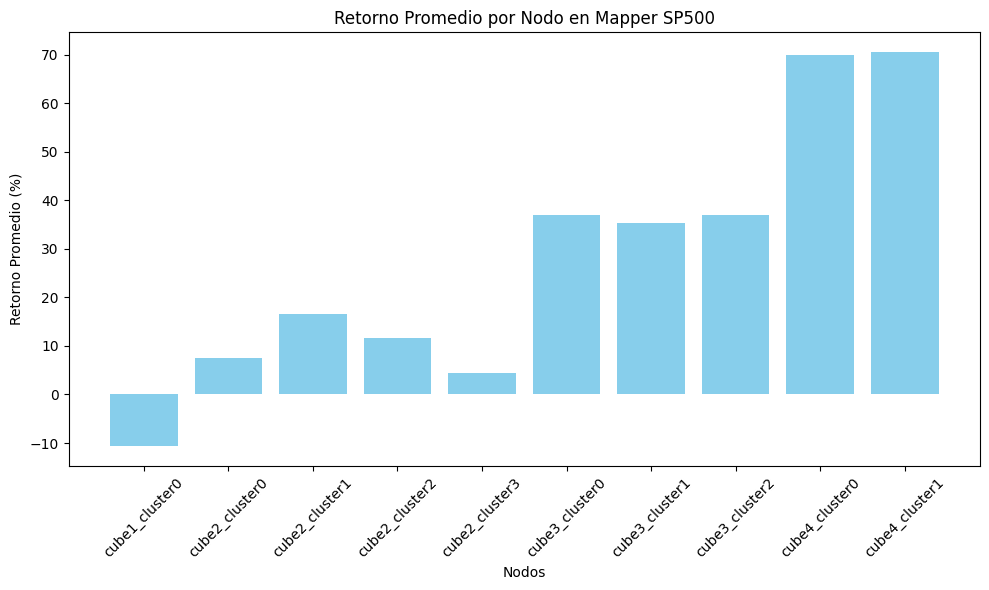

In [22]:
#Obtengamos una grafica de los retornos promedio por nodo
nodos = []
retornos_promedio = []
for node in graph['nodes']:
    indices = graph['nodes'][node]
    nodos.append(node)
    retornos_promedio.append(retornos_pct.iloc[indices].mean()) 
plt.figure(figsize=(10, 6))
plt.bar(nodos, retornos_promedio, color='skyblue')
plt.xlabel('Nodos')
plt.ylabel('Retorno Promedio (%)')
plt.title('Retorno Promedio por Nodo en Mapper SP500')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()  

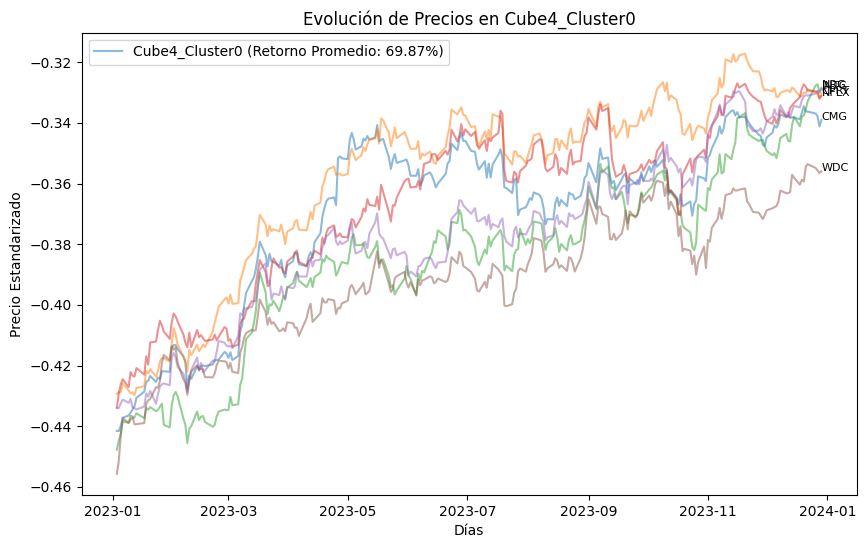

In [26]:
#Veamos la grafica de los datos en el cube4_cluster0 con el retorno promedio mas alto       
cube4_cluster0_indices = graph['nodes']['cube4_cluster0']
data_cube4_cluster0 = df_final.iloc[cube4_cluster0_indices]
plt.figure(figsize=(10, 6))
for i in range(data_cube4_cluster0.shape[0]):
    plt.plot(data_cube4_cluster0.columns, data_cube4_cluster0.iloc[i], alpha=0.5)
#Agreguemos la leyenda con el retorno promedio del nodo
retorno_promedio_cube4_cluster0 = retornos_pct.iloc[cube4_cluster0_indices].mean()
plt.legend([f'Cube4_Cluster0 (Retorno Promedio: {retorno_promedio_cube4_cluster0:.2f}%)'])

#Agreguemos etiquetas y título
plt.xlabel('Días')
plt.ylabel('Precio Estandarizado')
plt.title('Evolución de Precios en Cube4_Cluster0')
#Colocar mapa de las etiquetas de los elementos del nodo
for i in range(data_cube4_cluster0.shape[0]):
    plt.text(data_cube4_cluster0.columns[-1], data_cube4_cluster0.iloc[i, -1], data_cube4_cluster0.index[i], fontsize=8)
plt.show()
